In [3]:
# ==========================================
# Import Required Libraries
# ==========================================

import warnings
warnings.filterwarnings('ignore')

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Display Settings
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
# ==========================================
# Load the Dataset
# ==========================================

# Read the CSV file
df = pd.read_csv('/content/credit_risk_dataset.csv')

# Display confirmation
print("Dataset loaded successfully!")

Dataset loaded successfully!


In [5]:
# ==========================================
# Display First Five Rows
# ==========================================

df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [6]:
# ==========================================
# Check Dataset Shape
# ==========================================

print("Number of Rows :", df.shape[0])
print("Number of Columns :", df.shape[1])

Number of Rows : 32581
Number of Columns : 12


In [7]:
# ==========================================
# Display Column Names
# ==========================================

df.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [9]:
# ==========================================
# Statistical Summary
# ==========================================

df.describe(include='all')

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,32581,31686.000000,32581,32581,32581.000000,29465.000000,32581.000000,32581.000000,32581,32581.000000
unique,NaN,NaN,4,NaN,6,7,NaN,NaN,NaN,NaN,2,NaN
top,NaN,NaN,RENT,NaN,EDUCATION,A,NaN,NaN,NaN,NaN,N,NaN
freq,NaN,NaN,16446,NaN,6453,10777,NaN,NaN,NaN,NaN,26836,NaN
mean,27.734600,6.607485e+04,NaN,4.789686,NaN,NaN,9589.371106,11.011695,0.218164,0.170203,NaN,5.804211
std,6.348078,6.198312e+04,NaN,4.142630,NaN,NaN,6322.086646,3.240459,0.413006,0.106782,NaN,4.055001
min,20.000000,4.000000e+03,NaN,0.000000,NaN,NaN,500.000000,5.420000,0.000000,0.000000,NaN,2.000000
25%,23.000000,3.850000e+04,NaN,2.000000,NaN,NaN,5000.000000,7.900000,0.000000,0.090000,NaN,3.000000
50%,26.000000,5.500000e+04,NaN,4.000000,NaN,NaN,8000.000000,10.990000,0.000000,0.150000,NaN,4.000000
75%,30.000000,7.920000e+04,NaN,7.000000,NaN,NaN,12200.000000,13.470000,0.000000,0.230000,NaN,8.000000


PHASE-1 **EDA**

In [10]:
# ==========================================
# Dataset Shape
# ==========================================

print("Number of Rows :", df.shape[0])
print("Number of Columns :", df.shape[1])

Number of Rows : 32581
Number of Columns : 12


In [11]:
# ==========================================
# Missing Values
# ==========================================

df.isnull().sum()

,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,895
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,3116
loan_status,0
loan_percent_income,0


In [12]:
# ==========================================
# Duplicate Records
# ==========================================

print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 165


In [13]:
# ==========================================
# Target Variable Distribution
# ==========================================

df['loan_status'].value_counts()

,count
loan_status,
0,25473
1,7108


In [14]:
df['loan_status'].value_counts(normalize=True) * 100

,proportion
loan_status,
0,78.183604
1,21.816396


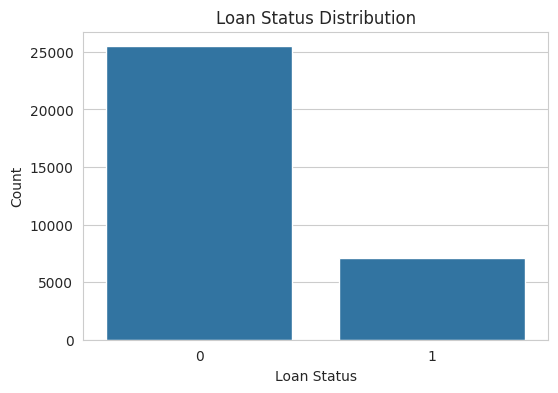

In [15]:
# ==========================================
# Loan Status Distribution
# ==========================================

plt.figure(figsize=(6,4))

sns.countplot(x='loan_status', data=df)

plt.title("Loan Status Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Count")

plt.show()

**Phase 2 – Numerical Feature Analysis**

In [16]:
# ==========================================
# Separate Numerical and Categorical Columns
# ==========================================

numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns
categorical_columns = df.select_dtypes(include=['object']).columns

print("Numerical Columns:\n")
print(numerical_columns)

print("\nCategorical Columns:\n")
print(categorical_columns)

Numerical Columns:

Index(['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_cred_hist_length'],
      dtype='object')

Categorical Columns:

Index(['person_home_ownership', 'loan_intent', 'loan_grade',
       'cb_person_default_on_file'],
      dtype='object')


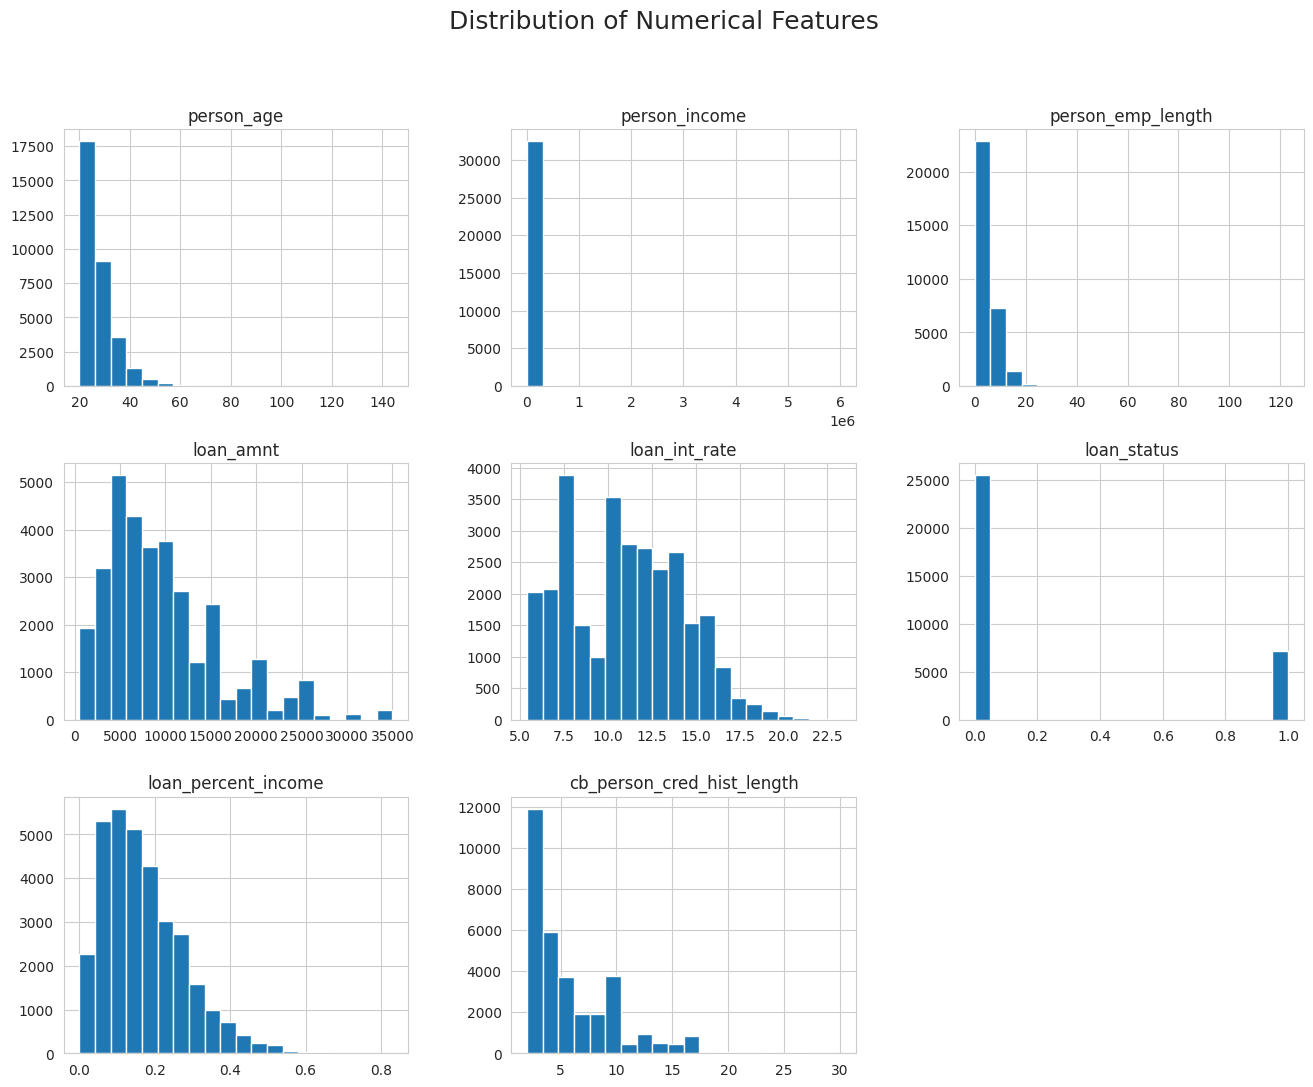

In [17]:
# ==========================================
# Histograms of Numerical Features
# ==========================================

df[numerical_columns].hist(figsize=(16,12), bins=20)

plt.suptitle("Distribution of Numerical Features", fontsize=18)

plt.show()

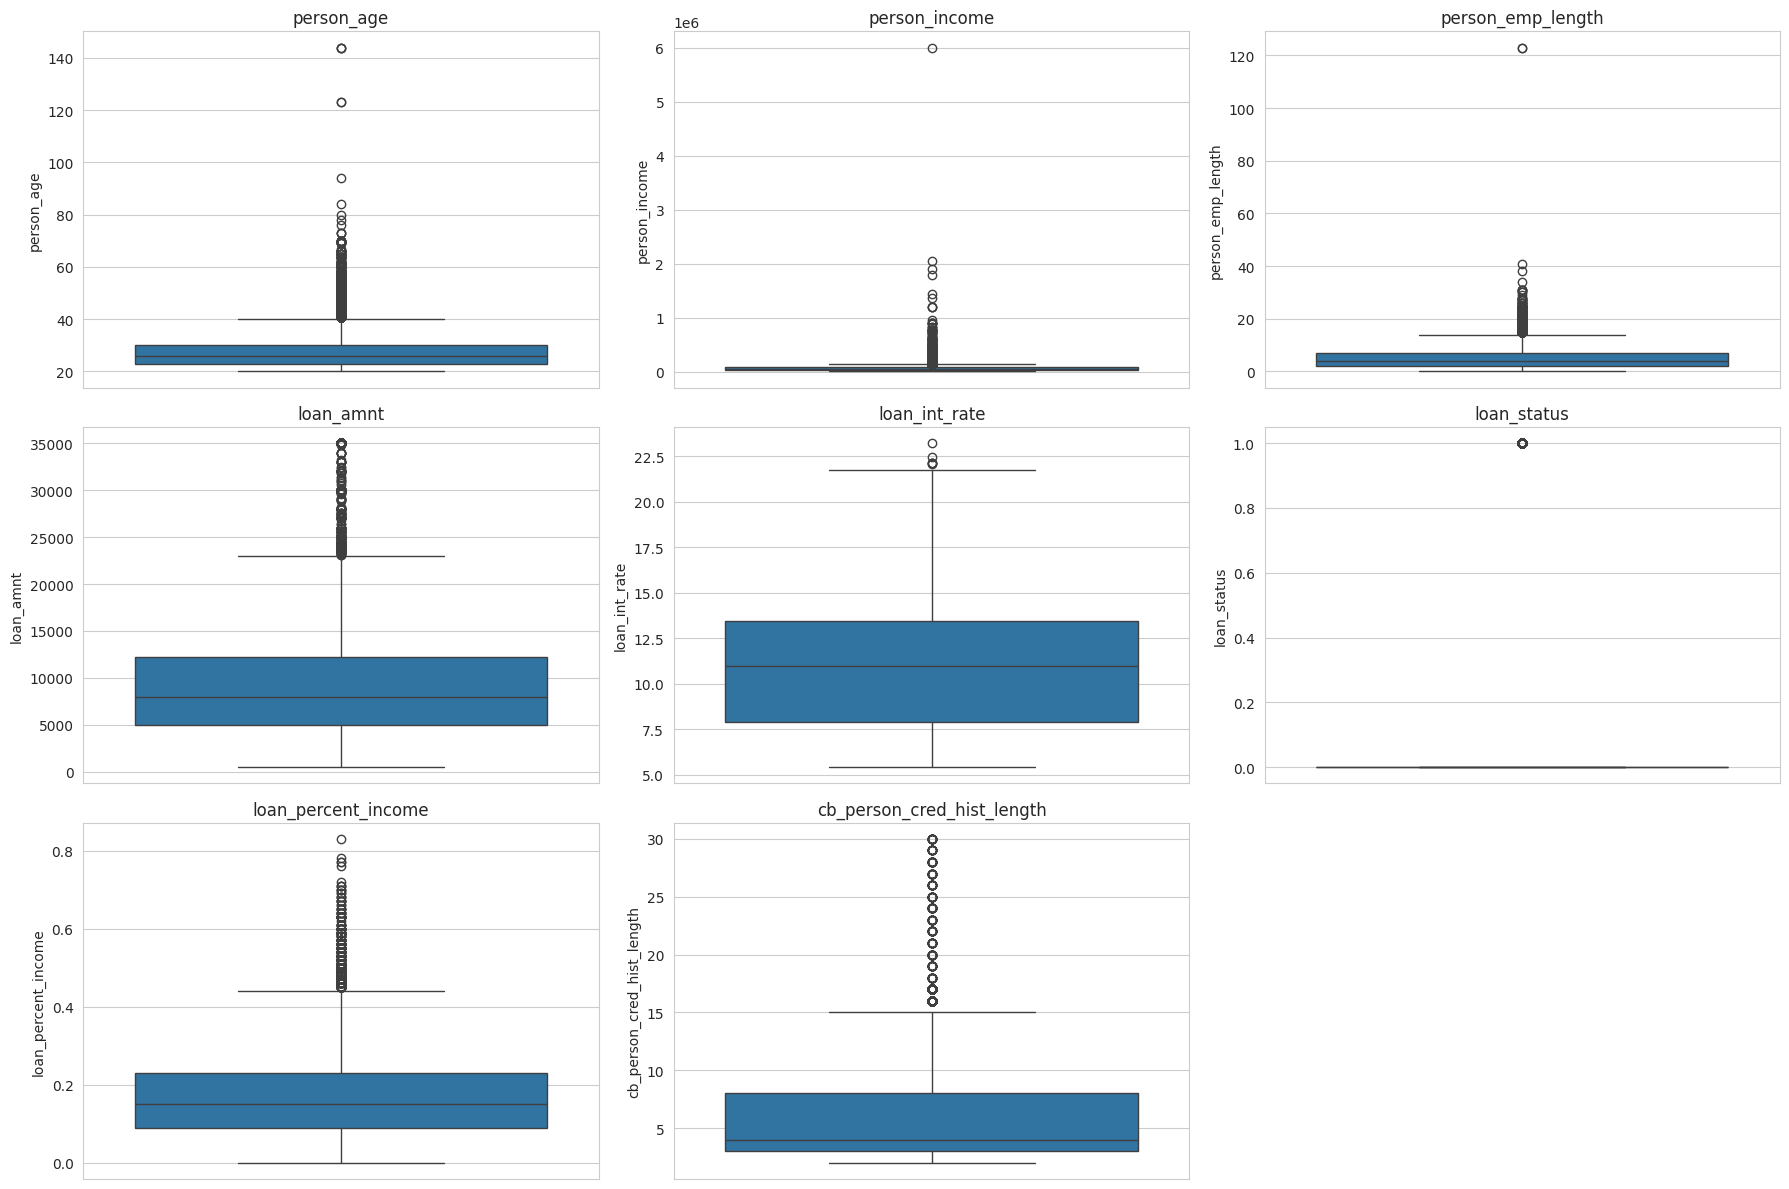

In [18]:
# ==========================================
# Boxplots
# ==========================================

plt.figure(figsize=(18,12))

for i, column in enumerate(numerical_columns):
    plt.subplot(3,3,i+1)
    sns.boxplot(y=df[column])
    plt.title(column)

plt.tight_layout()
plt.show()

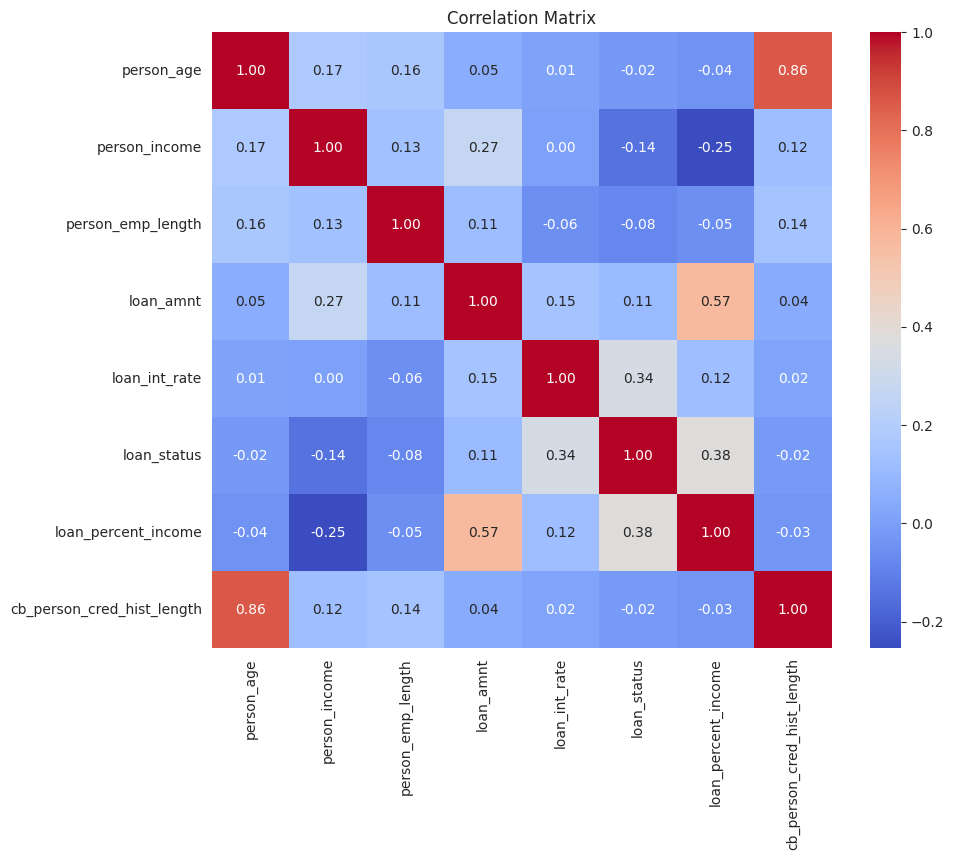

In [19]:
# ==========================================
# Correlation Matrix
# ==========================================

plt.figure(figsize=(10,8))

sns.heatmap(df[numerical_columns].corr(),
            annot=True,
            cmap='coolwarm',
            fmt=".2f")

plt.title("Correlation Matrix")

plt.show()

In [20]:
# ==========================================
# Correlation with Target Variable
# ==========================================

correlation = df[numerical_columns].corr()['loan_status'].sort_values(ascending=False)

print(correlation)

loan_status                   1.000000
loan_percent_income           0.379366
loan_int_rate                 0.335133
loan_amnt                     0.105376
cb_person_cred_hist_length   -0.015529
person_age                   -0.021629
person_emp_length            -0.082489
person_income                -0.144449
Name: loan_status, dtype: float64


**Phase3-Data Preprocessing**

In [21]:
# ==========================================
# Phase 3 - Data Preprocessing
# Step 3.1 - Check Missing Values
# ==========================================

print(df.isnull().sum())

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64


In [22]:
# ==========================================
# Step 3.2 - Handle Missing Values
# ==========================================

df["person_emp_length"] = df["person_emp_length"].fillna(
    df["person_emp_length"].median()
)

df["loan_int_rate"] = df["loan_int_rate"].fillna(
    df["loan_int_rate"].median()
)

print("Missing Values After Imputation")

print(df.isnull().sum())

Missing Values After Imputation
person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64


In [23]:
# ==========================================
# Step 3.3 - Identify Categorical Features
# ==========================================

categorical_columns = df.select_dtypes(include=["object"]).columns

print(categorical_columns)


Index(['person_home_ownership', 'loan_intent', 'loan_grade',
       'cb_person_default_on_file'],
      dtype='object')


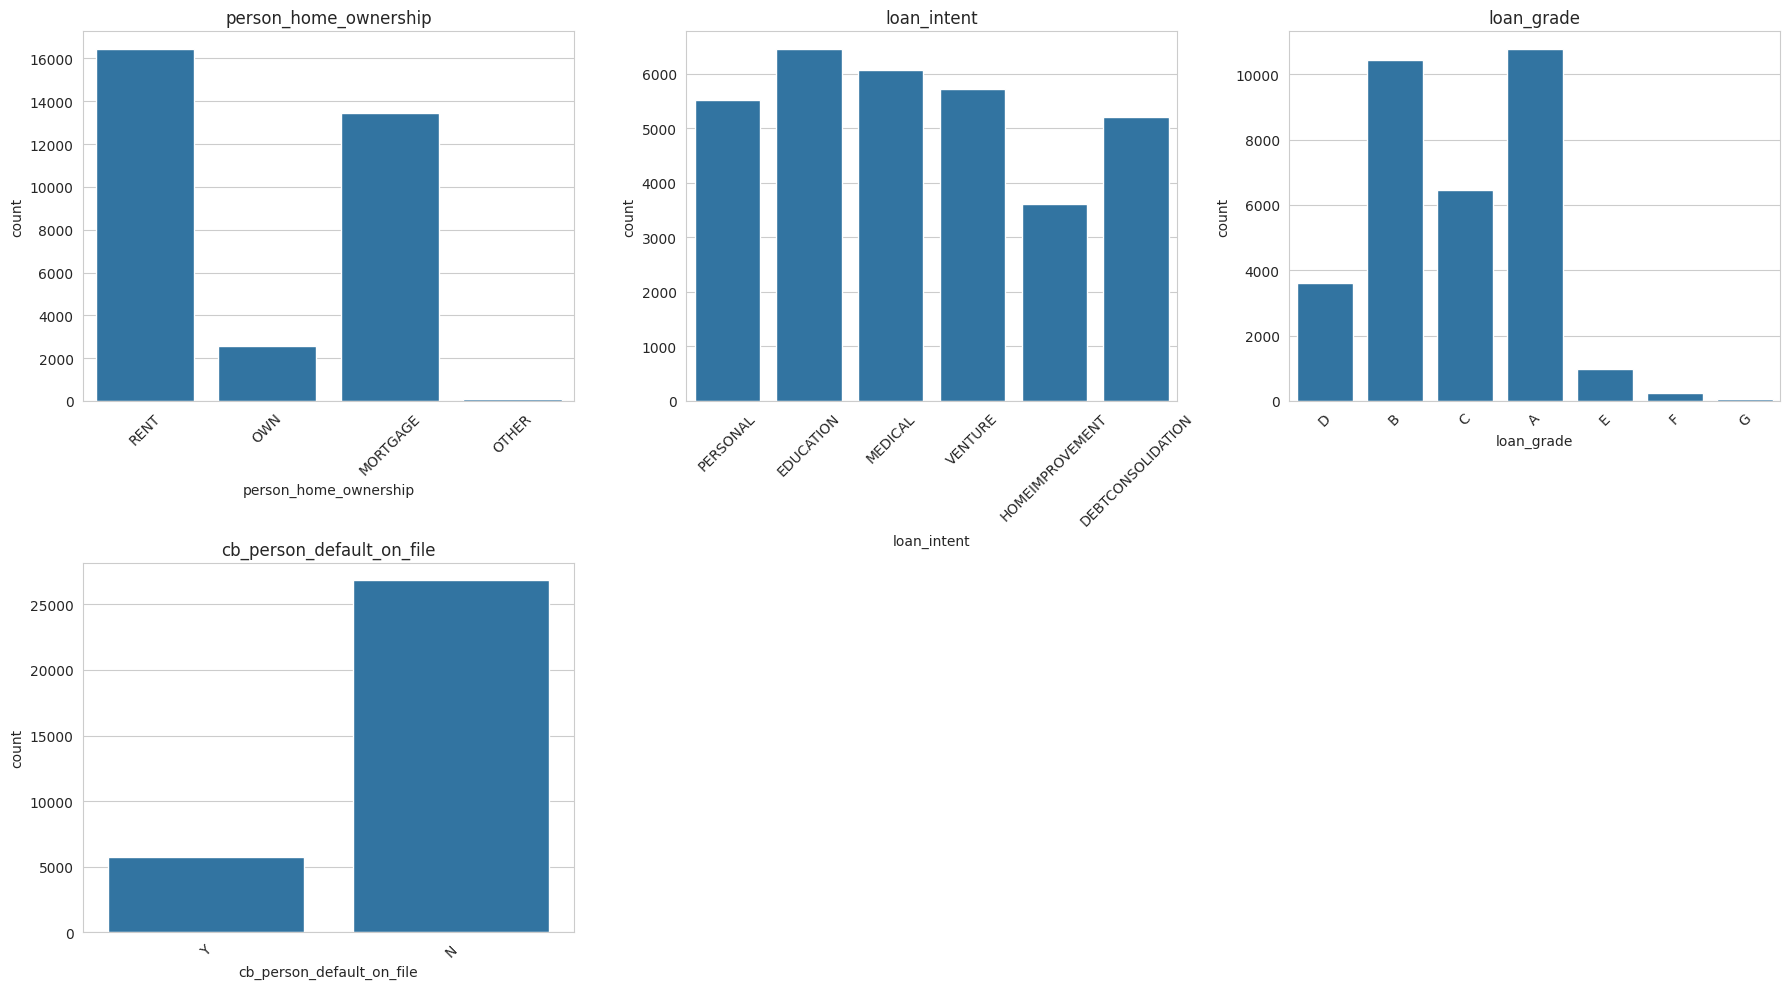

In [24]:
# ==========================================
# Step 3.4 - Distribution of Categorical Features
# ==========================================

plt.figure(figsize=(18,10))

for i, column in enumerate(categorical_columns):
    plt.subplot(2,3,i+1)
    sns.countplot(data=df, x=column)
    plt.xticks(rotation=45)
    plt.title(column)

plt.tight_layout()
plt.show()

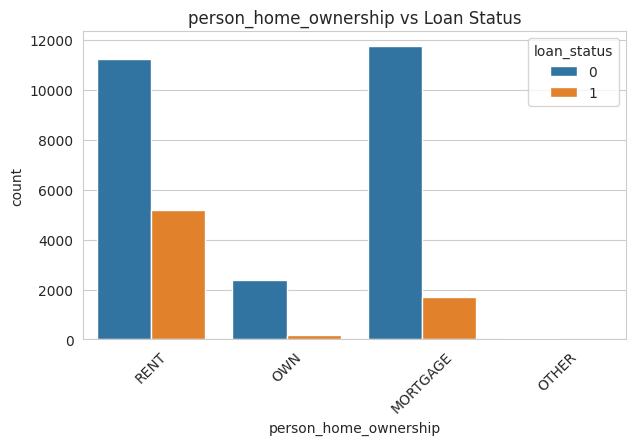

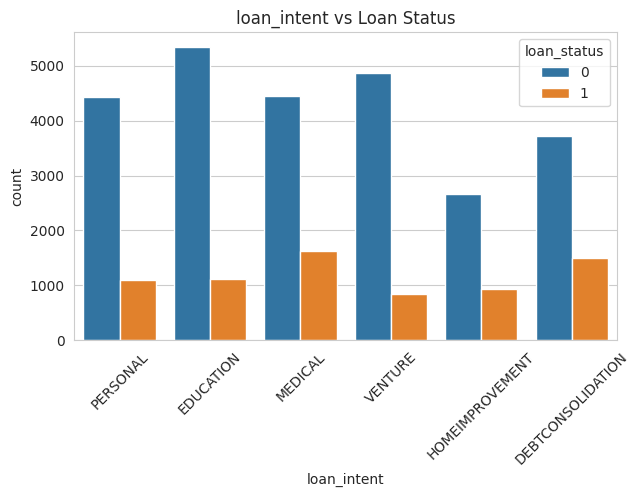

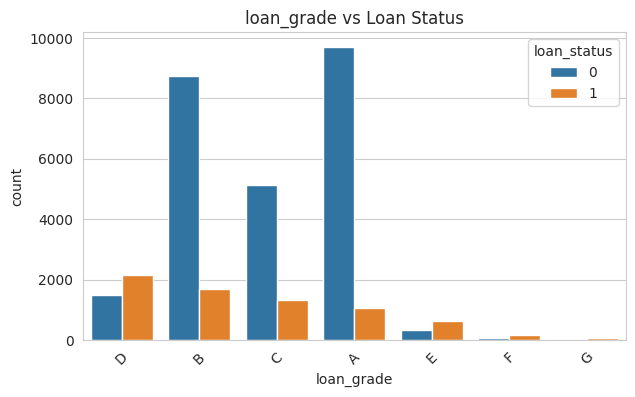

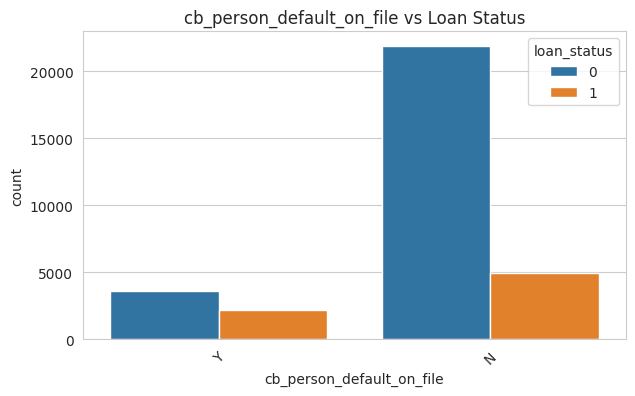

In [25]:
# ==========================================
# Step 3.5 - Categorical Features vs Target
# ==========================================

for column in categorical_columns:

    plt.figure(figsize=(7,4))

    sns.countplot(
        data=df,
        x=column,
        hue="loan_status"
    )

    plt.xticks(rotation=45)
    plt.title(f"{column} vs Loan Status")

    plt.show()

In [26]:
# ==========================================
# Step 3.6 - Label Encoding
# ==========================================

from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

for column in categorical_columns:
    df[column] = encoder.fit_transform(df[column])

print("Categorical Features Encoded Successfully.")

Categorical Features Encoded Successfully.


In [27]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,3,123.0,4,3,35000,16.02,1,0.59,1,3
1,21,9600,2,5.0,1,1,1000,11.14,0,0.10,0,2
2,25,9600,0,1.0,3,2,5500,12.87,1,0.57,0,3
3,23,65500,3,4.0,3,2,35000,15.23,1,0.53,0,2
4,24,54400,3,8.0,3,2,35000,14.27,1,0.55,1,4


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  int64  
 3   person_emp_length           32581 non-null  float64
 4   loan_intent                 32581 non-null  int64  
 5   loan_grade                  32581 non-null  int64  
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               32581 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  int64  
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(9)
memory usage: 3.0 MB


In [29]:
# ==========================================
# Step 3.8 - Feature and Target Split
# ==========================================

X = df.drop("loan_status", axis=1)

y = df["loan_status"]

print("Feature Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Shape : (32581, 11)
Target Shape : (32581,)


In [30]:
# ==========================================
# Step 3.9 - Train-Test Split
# ==========================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Set :", X_train.shape)
print("Testing Set :", X_test.shape)

Training Set : (26064, 11)
Testing Set : (6517, 11)


In [31]:
# ==========================================
# Step 3.10 - Feature Scaling
# ==========================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Feature Scaling Completed.")

Feature Scaling Completed.


In [32]:
print(df.isnull().sum())

print(X_train.isnull().sum())

import numpy as np

print(np.isnan(X_train_scaled).sum())

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64
person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64
0


**Phase 4 – Machine Learning Model Building**

In [33]:
# =====================================================
# Phase 4 - Machine Learning Model Building
# Step 4.1 - Logistic Regression
# =====================================================

from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

log_model.fit(X_train_scaled, y_train)

print("✅ Logistic Regression Model Trained Successfully!")

✅ Logistic Regression Model Trained Successfully!


In [34]:
# =====================================================
# Step 4.2 - Predictions
# =====================================================

y_pred = log_model.predict(X_test_scaled)

y_prob = log_model.predict_proba(X_test_scaled)[:,1]

In [35]:
# =====================================================
# Step 4.3 - Model Evaluation
# =====================================================

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))

Accuracy : 0.8448672702163572
Precision: 0.7241003271537623
Recall   : 0.4669479606188467
F1 Score : 0.5677640017101325
ROC AUC  : 0.8516006012347672


In [36]:
# =====================================================
# Step 4.4 - Classification Report
# =====================================================

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.95      0.91      5095
           1       0.72      0.47      0.57      1422

    accuracy                           0.84      6517
   macro avg       0.79      0.71      0.74      6517
weighted avg       0.83      0.84      0.83      6517



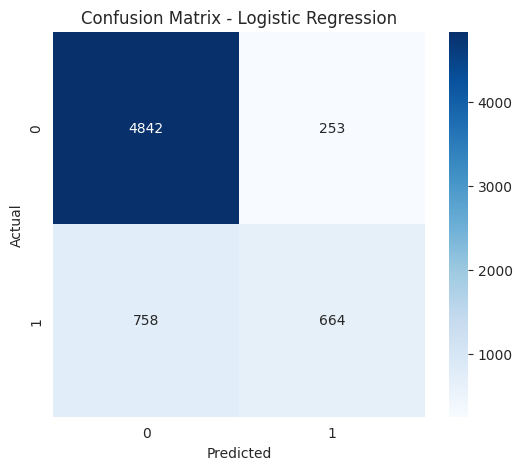

In [37]:
# =====================================================
# Step 4.5 - Confusion Matrix
# =====================================================

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix - Logistic Regression")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

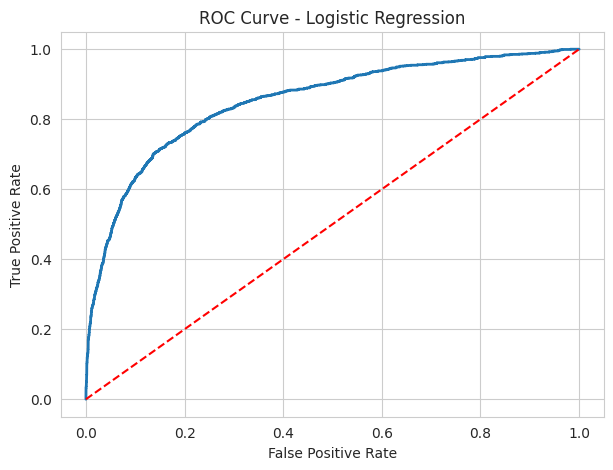

In [38]:
# =====================================================
# Step 4.6 - ROC Curve
# =====================================================

from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7,5))

plt.plot(fpr, tpr, linewidth=2)

plt.plot([0,1],[0,1],'r--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Logistic Regression")

plt.show()

**Phase 5 – Advanced Machine Learning Models**

In [39]:
# =====================================================
# Phase 5 - Advanced Machine Learning Models
# Step 5.1 - Decision Tree Classifier
# =====================================================

from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(X_train, y_train)

print("✅ Decision Tree Model Trained Successfully!")

✅ Decision Tree Model Trained Successfully!


In [40]:
# =====================================================
# Step 5.2 - Predictions
# =====================================================

dt_pred = dt_model.predict(X_test)

dt_prob = dt_model.predict_proba(X_test)[:,1]

In [41]:
# =====================================================
# Step 5.3 - Evaluation Metrics
# =====================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Accuracy :", accuracy_score(y_test, dt_pred))
print("Precision:", precision_score(y_test, dt_pred))
print("Recall   :", recall_score(y_test, dt_pred))
print("F1 Score :", f1_score(y_test, dt_pred))
print("ROC AUC  :", roc_auc_score(y_test, dt_prob))

Accuracy : 0.8916679453736381
Precision: 0.7462173314993122
Recall   : 0.7630098452883263
F1 Score : 0.7545201668984701
ROC AUC  : 0.8452929501220827


In [42]:
from sklearn.metrics import classification_report

print(classification_report(y_test, dt_pred))

              precision    recall  f1-score   support

           0       0.93      0.93      0.93      5095
           1       0.75      0.76      0.75      1422

    accuracy                           0.89      6517
   macro avg       0.84      0.85      0.84      6517
weighted avg       0.89      0.89      0.89      6517



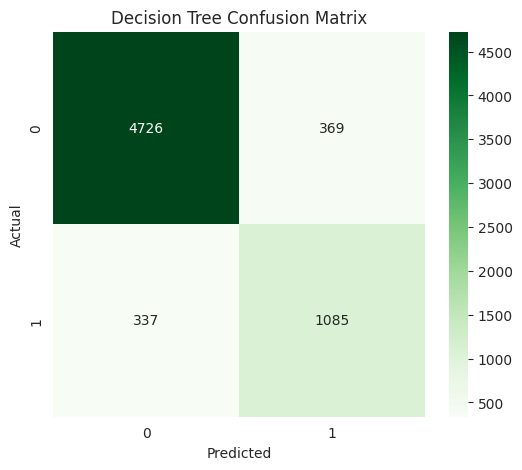

In [43]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, dt_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Decision Tree Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

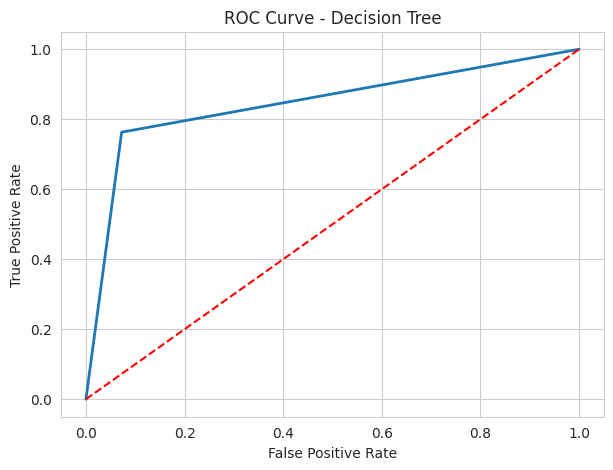

In [44]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, dt_prob)

plt.figure(figsize=(7,5))

plt.plot(fpr, tpr, linewidth=2)

plt.plot([0,1],[0,1],'r--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Decision Tree")

plt.show()

In [45]:
# =====================================================
# Step 5.7 - Random Forest Classifier
# =====================================================

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("✅ Random Forest Model Trained Successfully!")

✅ Random Forest Model Trained Successfully!


In [46]:
# =====================================================
# Step 5.8 - Predictions
# =====================================================

rf_pred = rf_model.predict(X_test)

rf_prob = rf_model.predict_proba(X_test)[:,1]

In [47]:
# =====================================================
# Step 5.9 - Evaluation Metrics
# =====================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall   :", recall_score(y_test, rf_pred))
print("F1 Score :", f1_score(y_test, rf_pred))
print("ROC AUC  :", roc_auc_score(y_test, rf_prob))

Accuracy : 0.9318704925579254
Precision: 0.9683908045977011
Recall   : 0.7109704641350211
F1 Score : 0.8199513381995134
ROC AUC  : 0.9285338760457083


In [48]:
from sklearn.metrics import classification_report

print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.92      0.99      0.96      5095
           1       0.97      0.71      0.82      1422

    accuracy                           0.93      6517
   macro avg       0.95      0.85      0.89      6517
weighted avg       0.93      0.93      0.93      6517



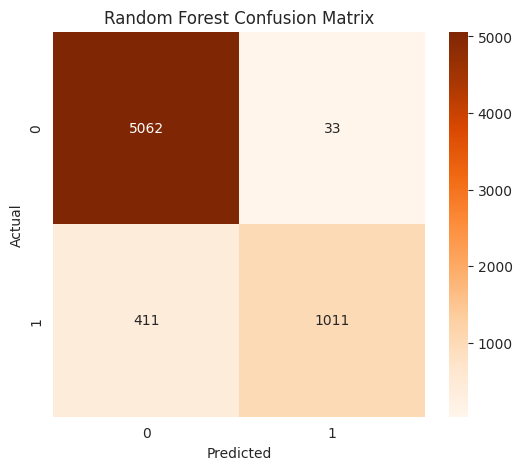

In [49]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Oranges"
)

plt.title("Random Forest Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

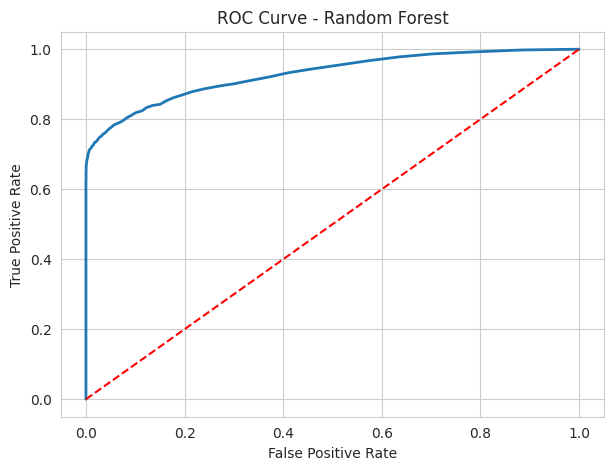

In [50]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, rf_prob)

plt.figure(figsize=(7,5))

plt.plot(fpr, tpr, linewidth=2)

plt.plot([0,1],[0,1],'r--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Random Forest")

plt.show()

In [ ]:
!pip install xgboost

In [ ]:
from xgboost import XGBClassifier

In [ ]:
# =====================================================
# Step 5.13 - XGBoost Classifier
# =====================================================

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

print("✅ XGBoost Model Trained Successfully!")

In [ ]:
# =====================================================
# Step 5.14 - Predictions
# =====================================================

xgb_pred = xgb_model.predict(X_test)

xgb_prob = xgb_model.predict_proba(X_test)[:,1]

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Accuracy :", accuracy_score(y_test, xgb_pred))
print("Precision:", precision_score(y_test, xgb_pred))
print("Recall   :", recall_score(y_test, xgb_pred))
print("F1 Score :", f1_score(y_test, xgb_pred))
print("ROC AUC  :", roc_auc_score(y_test, xgb_prob))

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, xgb_pred))

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, xgb_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Purples"
)

plt.title("Confusion Matrix - XGBoost")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, xgb_prob)

plt.figure(figsize=(7,5))

plt.plot(fpr, tpr, linewidth=2)

plt.plot([0,1],[0,1],'r--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve - XGBoost")

plt.show()

**Phase 6 – Model Comparison & Feature Importance**

In [ ]:
# =====================================================
# Phase 6 - Model Comparison
# =====================================================

import pandas as pd

comparison = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],

    "Accuracy":[
        0.8449,
        0.8917,
        0.9319,
        0.9336
    ],

    "Precision":[
        0.7241,
        0.7462,
        0.9684,
        0.9750
    ],

    "Recall":[
        0.4669,
        0.7630,
        0.7100,
        0.7138
    ],

    "F1 Score":[
        0.5678,
        0.7545,
        0.8199,
        0.8242
    ],

    "ROC AUC":[
        0.8516,
        0.8453,
        0.9285,
        0.9439
    ]

})

comparison

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=comparison,
    x="Model",
    y="Accuracy"
)

plt.title("Accuracy Comparison")

plt.xticks(rotation=20)

plt.show()

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=comparison,
    x="Model",
    y="ROC AUC"
)

plt.title("ROC-AUC Comparison")

plt.xticks(rotation=20)

plt.show()

In [ ]:
importance = pd.Series(
    xgb_model.feature_importances_,
    index=X_train.columns
)

importance = importance.sort_values(ascending=False)

importance

In [ ]:
plt.figure(figsize=(10,6))

importance.plot(kind="bar")

plt.title("Feature Importance - XGBoost")

plt.show()

**Final Phase (Phase 7)**

In [ ]:
import joblib

joblib.dump(xgb_model, "credit_risk_xgboost.pkl")

print("Model saved successfully!")